In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['pdf.fonttype'] = 42   
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
import scanpy.external as sce
import os
import pickle

In [3]:
import PyComplexHeatmap
from PyComplexHeatmap import *

In [12]:
sns.set_style('ticks')

In [5]:
sc.settings.verbosity = 3 
sc.settings.set_figure_params(dpi=100, dpi_save=300,
                              facecolor='white', figsize=(4,4))

In [6]:
import scipy
import pingouin as pg

In [30]:
adata = sc.read_h5ad('./data/RNA.merged.analysed.h5ad')

In [135]:
meta = adata.obs.loc[~adata.obs['celltype'].isin(['others', 'Platelet']),].copy()
meta = meta.loc[meta['coarse_condition'] != 'B',]
meta['celltype'] = meta['celltype'].astype('object') 
meta['refined_celltype'] = meta['refined_celltype'].astype('object') 
meta['coarse_condition'] = meta['coarse_condition'].astype('object') 

In [158]:
P_values = {}

In [141]:
df1 = meta.groupby(['celltype', 'sample'], observed=True)['refined_celltype'].value_counts(normalize=True).reset_index(name='ratio')
df1['condition'] = [i[-1] for i in df1['sample']]
df1 = df1.loc[~df1['celltype'].isin(['SG Epithelium', 'Mast cell', 'Myoblast']),]

In [144]:
trans_df1 = df1.groupby(['refined_celltype', 'condition'])['ratio'].mean().reset_index(name='ratio')
trans_df1 = trans_df1.pivot_table(values='ratio', index='condition', columns='refined_celltype')

In [8]:
for ct in df1['refined_celltype'].unique():
    stat = pg.kruskal(data=df1.loc[df1['refined_celltype']==ct, ], dv='ratio', between='condition')
    P_values[ct] = stat.iloc[0,3]

In [145]:
df2 = meta.groupby('sample', observed=True)['celltype'].value_counts(normalize=True).reset_index(name='ratio')
df2['condition'] = [i[-1] for i in df2['sample']]
df2 = df2.loc[df2['celltype'].isin(['SG Epithelium', 'Mast cell', 'Myoblast']),]

In [9]:
for ct in df2['celltype'].unique():
    stat = pg.kruskal(data=df2.loc[df2['celltype']==ct, ], dv='ratio', between='condition')
    P_values[ct] = stat.iloc[0,3]

In [147]:
trans_df2 = df2.groupby(['celltype', 'condition'])['ratio'].mean().reset_index(name='ratio')
trans_df2 = trans_df2.pivot_table(values='ratio', index='condition', columns='celltype')

In [151]:
trans_df = pd.concat([trans_df1, trans_df2], axis=1)
trans_df.to_csv('./cell_subtypes_proportion.csv')

In [161]:
P_df = pd.DataFrame(P_values, index=['P_values'])
P_df = P_df.T
P_df.to_csv('./P_df.csv')

<Figure size 2500x150 with 0 Axes>

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting legends..


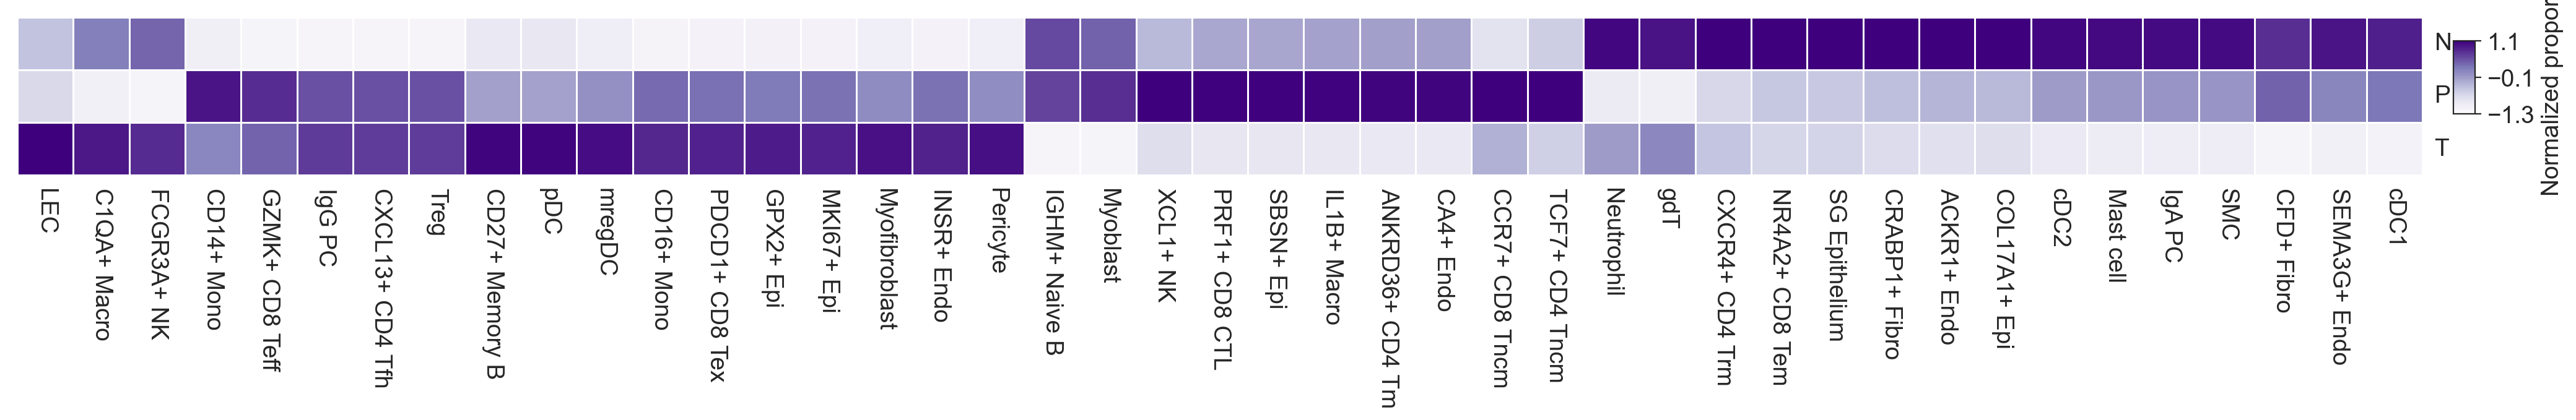

In [13]:
plt.figure(figsize=(25, 1.5))
cm2 = ClusterMapPlotter(data=trans_df, 
                       z_score=1,
                       vmax=1.1, vmin=-1.3, 
                       cmap='Purples',   
                       show_rownames=True, show_colnames=True,
                       row_cluster=False, col_cluster=False,  legend=True,
                        legend_width=2, linecolor='white',linewidths=0.5, label='Normalized proportion')
# plt.savefig('./cell_subtype_proportion.pdf', dpi=300, bbox_inches='tight')

In [10]:
DEGs = {}
for i in meta.refined_celltype.unique():
    if i != 'Platelet':
        print(i)
        tmp = adata[adata.obs['refined_celltype']==i,]
        sc.tl.rank_genes_groups(tmp, groupby='coarse_condition', groups=['T', 'P'], reference='N', method='wilcoxon' )    #, method='t-test_overestim_var' wilcoxon
        DEG = sc.get.rank_genes_groups_df(tmp, group=None)    
        DEGs[i] = DEG
        print('-------------------------')

In [195]:
DGE_num = pd.DataFrame(index = list(DEGs.keys()), columns = ['T_up', 'T_down', 'P_up', 'P_down'])
for i in meta.refined_celltype.unique():
    if i != 'Platelet':
        DEG = DEGs[i]
        T_up = DEG.loc[(DEG['logfoldchanges'] > np.log2(2))&(DEG['scores'] > 6)&(DEG['pvals_adj']<0.01)&(DEG['group']=='T'),].shape[0]
        T_down = DEG.loc[(DEG['logfoldchanges'] < -np.log2(2))&(DEG['scores'] < -6)&(DEG['pvals_adj']<0.01)&(DEG['group']=='T'),].shape[0]
        
        P_up = DEG.loc[(DEG['logfoldchanges'] > np.log2(2))&(DEG['scores'] > 6)&(DEG['pvals_adj']<0.01)&(DEG['group']=='P'),].shape[0]
        P_down = DEG.loc[(DEG['logfoldchanges'] < -np.log2(2))&(DEG['scores'] < -6)&(DEG['pvals_adj']<0.01)&(DEG['group']=='P'),].shape[0]
        DGE_num.loc[i, 'T_up'] = T_up
        DGE_num.loc[i, 'T_down'] = T_down
        DGE_num.loc[i, 'P_up'] = P_up
        DGE_num.loc[i, 'P_down'] = P_down
        
DGE_num['P'] = DGE_num[['P_up', 'P_down']].sum(axis=1).values 
DGE_num['T'] = DGE_num[['T_up', 'T_down']].sum(axis=1).values 

In [207]:
DGE_num.to_csv('.DGE_num.csv')

<Figure size 2500x100 with 0 Axes>

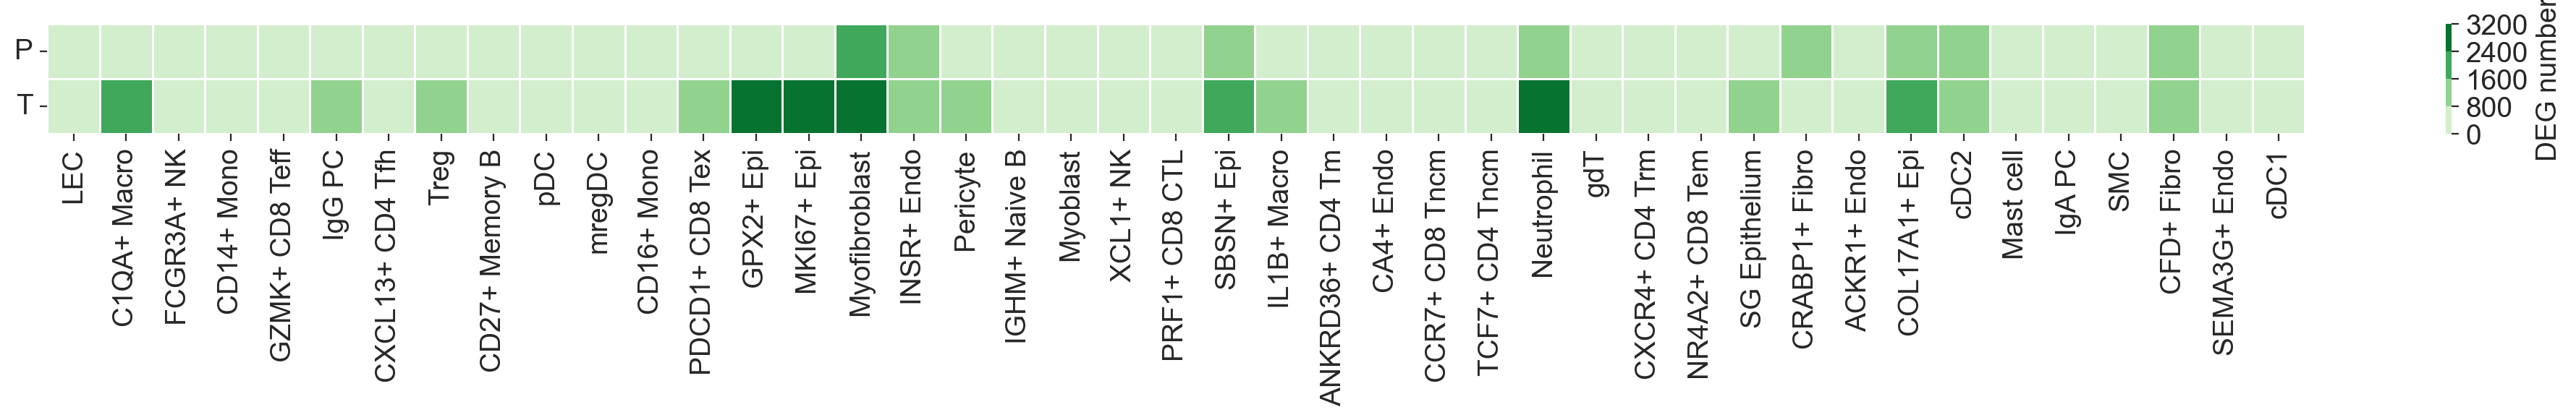

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
plot_data = DGE_num.loc[:,['P', 'T']].T.clip(upper=3200)
num_levels = 4
base_cmap = plt.get_cmap('Greens')
colors = base_cmap(np.linspace(0.2, 0.85, num_levels))
cmap = mcolors.ListedColormap(colors)
bounds = [0, 800, 1600, 2400, 3200]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(25, 1)) 
sns_heatmap = sns.heatmap(
    plot_data, 
    cmap=cmap, 
    norm=norm,
    annot=False,         
    linewidths=1,         
    linecolor='white',   
    square=False,         
    cbar_kws={
        "ticks": bounds, 
        "label": 'DEG number',
        "orientation": "vertical",
        "spacing": 'proportional'  
    }
)
_ = plt.xticks(rotation=90)
_ = plt.yticks(rotation=0)  
# plt.savefig('./Heatmap_number.pdf', bbox_inches='tight', dpi=300)